In [133]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from KCircles import KCircles

# Génerer les données

In [134]:
size = 150
r = 0.7
gap = 1.2
C = np.array([[0, 0], [2, 0], [4, 0], [1, -gap], [3, -gap]])
X = []
for c in C:
    data = make_circles(2*size, noise=0.1)
    X_ = data[0][data[1]==0] + c
    X.append(X_)
X = np.concatenate(X)

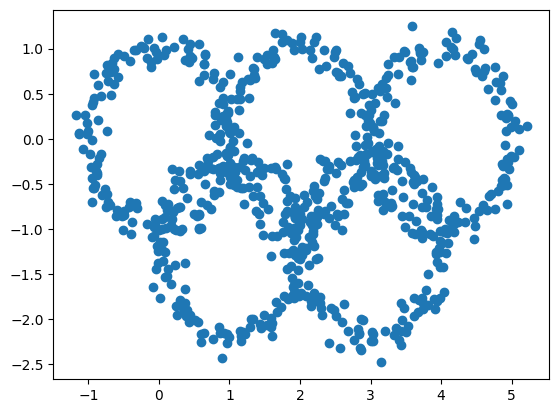

In [135]:
plt.scatter(X[:, 0], X[:, 1])

# Entrainement

In [136]:
model = KCircles(5)
model.multi_fit(X, 200, 30)
model.fit(X, iter=3000, init=False)

In [137]:
C = model.centers.copy()
histo = model.histo
y = model.predict(X)

# Résultats

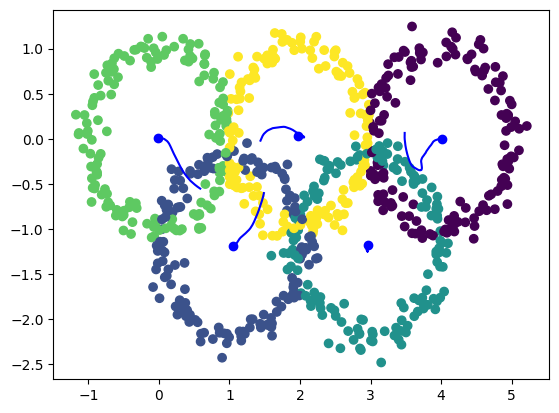

In [138]:
X_histo, Y_histo = np.array(histo).T
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.scatter(C[:, 0], C[:, 1], c='blue')
for j in range(len(X_histo)):
    plt.plot(X_histo[j], Y_histo[j], c='blue')

In [139]:
X.std(axis=0)

array([1.58392511, 0.92277884])

In [140]:
_, loss = model.predict(X, loss=True)
loss

6.183536901115529

In [141]:
nb_err = 0
err = []
for j in range(5):
    y_ = y[j*150:(j+1)*150]
    nb_err += (y_ != np.bincount(y_).argmax()).sum()
    err.append((y_ != np.bincount(y_).argmax()))
err = np.concatenate(err)
nb_err, nb_err/len(y)

(108, 0.144)

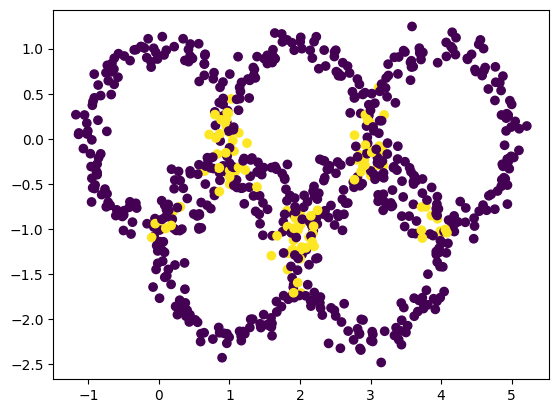

In [142]:
plt.scatter(X[:, 0], X[:, 1], c=err)